In [114]:
import os
import json
import humanize
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

In [115]:
data = []
for fn in os.listdir("./projectile-data"):
  if fn.endswith(".json"):
    with open(f"./projectile-data/{fn}", "r") as f:
      raw = json.load(f)
      data += raw['data']

In [119]:
df = pd.json_normalize(data)
# df['position.x'] = df['position.x'].apply(lambda x: -x)
df['velocity_length'] = (df['velocity.x']**2 + df['velocity.y']**2 + df['velocity.z']**2)**0.5
df['energy'] = (df['ammo_properties.mass'] * df['velocity_length']**2) / 2
df

,distance,draw_frame,fragmentation_count,id,impact_count,penetration_count,physics_frame,ricochet_count,time,total_substeps,...,ammo_properties.drag_coef,ammo_properties.mass,position.x,position.y,position.z,velocity.x,velocity.y,velocity.z,velocity_length,energy
0,24.981808,1272,0,1271_1045_1271,0,0,1046,0,1.752516e+09,1,...,0.28,4.1,13.819255,1.153091,-21.140041,648.677795,-2.800449,-655.096252,921.922895,1.742381e+06
1,25.357641,1272,0,1271_1045_1271,0,0,1046,0,1.752516e+09,2,...,0.28,4.1,14.089515,1.151924,-21.412975,648.623901,-2.801029,-655.041016,921.845726,1.742089e+06
2,25.733690,1272,0,1271_1045_1271,0,0,1046,0,1.752516e+09,3,...,0.28,4.1,14.359753,1.150757,-21.685886,648.570068,-2.801608,-654.985779,921.768601,1.741798e+06
3,26.109940,1272,0,1271_1045_1271,0,0,1046,0,1.752516e+09,4,...,0.28,4.1,14.629968,1.149589,-21.958773,648.516235,-2.802188,-654.930542,921.691475,1.741506e+06
4,26.486382,1272,0,1271_1045_1271,0,0,1046,0,1.752516e+09,5,...,0.28,4.1,14.900161,1.148421,-22.231638,648.462402,-2.802767,-654.875305,921.614349,1.741215e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,44.144634,2342,0,2341_1924_2341,0,0,1925,0,1.752516e+09,51,...,0.28,4.1,25.045174,3.771182,-36.528507,542.177063,119.299438,-731.207520,918.070128,1.727848e+06
2194,44.526501,2342,0,2341_1924_2341,0,0,1925,0,1.752516e+09,52,...,0.28,4.1,25.271061,3.820885,-36.833153,542.132385,119.288605,-731.146118,917.993432,1.727559e+06
2195,44.908352,2342,0,2341_1924_2341,0,0,1925,0,1.752516e+09,53,...,0.28,4.1,25.496931,3.870584,-37.137772,542.087708,119.277771,-731.084717,917.916735,1.727271e+06
2196,45.290173,2342,0,2341_1924_2341,0,0,1925,0,1.752516e+09,54,...,0.28,4.1,25.722782,3.920279,-37.442364,542.043030,119.266937,-731.023315,917.840038,1.726982e+06


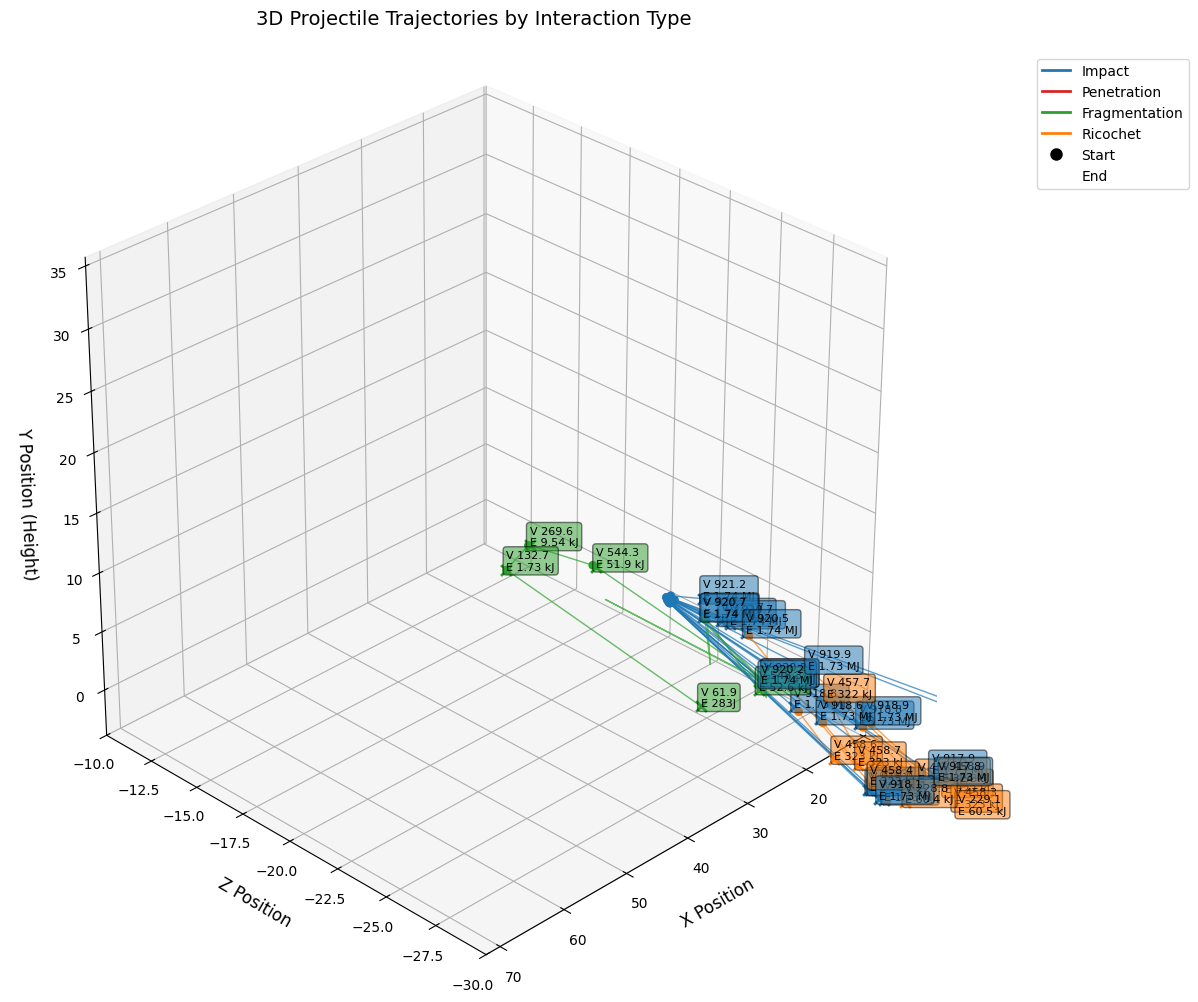

In [122]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

# Сгруппируем данные по ID снаряда (если есть) или сгенерируем уникальные группы
if 'id' in df.columns:
  groups = df.groupby('id')
else:
  # Создаем искусственные группы по последовательности событий
  df['group_id'] = (df['physics_frame'].diff() > 1).cumsum()
  groups = df.groupby('group_id')

# Цветовая схема взаимодействий
interaction_colors = {
  'impact': '#1f77b4',      # Синий - обычное попадание
  'penetration': '#d62728', # Красный - пробитие
  'fragmentation': '#2ca02c', # Зеленый - фрагментация
  'ricochet': '#ff7f0e'     # Оранжевый - рикошет
}

# Определение координатных столбцов
x_col = 'position.x'
y_col = 'position.z' 
z_col = 'position.y'  # Высота

# Создаем 3D график
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1, 1, 1])
ax.set_ylim(-10, -30)

# Функция для определения типа взаимодействия
def get_interaction_type(group):
  last_row = group.iloc[-1]
  if last_row['penetration_count'] > 0:
    return 'penetration'
  elif last_row['fragmentation_count'] > 0:
    return 'fragmentation'
  elif last_row['ricochet_count'] > 0:
    return 'ricochet'
  else:
    return 'impact'

# Подготовка данных с типами
typed_groups = []
for name, group in groups:
  int_type = get_interaction_type(group)
  typed_groups.append((name, group, int_type))

# Отрисовка траекторий
for name, group, int_type in typed_groups:
  # Траектория
  ax.plot(group[x_col], group[y_col], group[z_col],
          color=interaction_colors[int_type],
          linewidth=1,
          zorder=20,
          alpha=0.7)
  
  # Начальная точка
  ax.scatter(group[x_col].iloc[0], group[y_col].iloc[0], group[z_col].iloc[0],
             color=interaction_colors[int_type],
             marker='o',
             s=40,
             edgecolor='none',
             zorder=50,
             depthshade=False)
  
  # Конечная точка
  ax.scatter(group[x_col].iloc[-1], group[y_col].iloc[-1], group[z_col].iloc[-1],
             color=interaction_colors[int_type],
             marker='x',
             s=60,
             linewidth=2,
             zorder=100,
             depthshade=False)

# Настройка легенды
legend_elements = [
  Line2D([0], [0], color=interaction_colors['impact'], lw=2, label='Impact'),
  Line2D([0], [0], color=interaction_colors['penetration'], lw=2, label='Penetration'),
  Line2D([0], [0], color=interaction_colors['fragmentation'], lw=2, label='Fragmentation'),
  Line2D([0], [0], color=interaction_colors['ricochet'], lw=2, label='Ricochet'),
  Line2D([0], [0], marker='o', color='w', label='Start',
         markerfacecolor='black', markersize=10),
  Line2D([0], [0], marker='x', color='w', label='End',
         markerfacecolor='black', markersize=10)
]

# Настройки графика
ax.set_title('3D Projectile Trajectories by Interaction Type', pad=20, fontsize=14)
ax.set_xlabel('X Position', fontsize=12, labelpad=10)
ax.set_ylabel('Z Position', fontsize=12, labelpad=10)
ax.set_zlabel('Y Position (Height)', fontsize=12, labelpad=10)
ax.legend(handles=legend_elements, bbox_to_anchor=(1.1, 1), loc='upper left')
ax.grid(True, alpha=0.2)

# Добавление аннотаций
for name, group, int_type in typed_groups:
  last_row = group.iloc[-1]
  info_text = ''
  # info_text = f"I:{last_row['impact_count']}"
  # if last_row['penetration_count'] > 0:
  #   info_text += f" P:{last_row['penetration_count']}"
  # if last_row['fragmentation_count'] > 0:
  #   info_text += f" F:{last_row['fragmentation_count']}"
  # if last_row['ricochet_count'] > 0:
  #   info_text += f" R:{last_row['ricochet_count']}"
  info_text += f"V {round(last_row['velocity_length'], 1)}"
  info_text += f"\nE {humanize.metric(last_row['energy'])}J"
  
  ax.text(last_row[x_col], last_row[y_col], last_row[z_col],
          info_text,
          fontsize=8,
          bbox=dict(boxstyle='round,pad=0.3',
                   fc=interaction_colors[int_type],
                   alpha=0.5),
          zorder=1000)

# Установка угла обзора
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()